# Badanie Sieci neuronowej

In [1]:
from baza import wczytanie, czyszczenie, wykresy_podstawowe, analiza_jakosci, mapa_korelacji_top12, analiza_jakosci
from siec_neuronowa import initialize_model, setup_optimization, get_device, get_telco_loaders, run_step, run_experiment, evaluate_best_model, execute_series, plot_series_results, plot_confusion_matrix_heatmap, plot_single_history_overfitting

raw_df = wczytanie()
cleaned_df = czyszczenie(raw_df)

target_classes = ['Zostaje (No)', 'Odchodzi (Yes)']
device = get_device()

C:\Users\Piotrek\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WCZYTANIE DANYCH
Liczba rekordów: 7043

TYPY DANYCH (POCZĄTKOWE):
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

CZYSZCZENIE DANYCH
Liczba wykrytych braków (NaN) po konwersji: 11

FINALNE TYPY KLUCZOWYCH DANYCH:
TotalCharges    float64
Churn             int64
dtype: object

Wykorzystywane urządzenie: CPU



In [2]:
base_config = {
        "batch_size": 64,
        "hidden_layers": [128, 64],  
        "dropout": 0.3,
        "lr": 0.005,
        "optimizer_type": "adam",
        "epochs": 30
    }

In [3]:
train_loader, test_loader, input_features_dim = get_telco_loaders(cleaned_df, batch_size=base_config["batch_size"])
print(f"Liczba cech wejściowych po kodowaniu One-Hot: {input_features_dim}")

# przeprowadzenie głównego testu sieci i generowanie dowodu na overfitting
print("Główny eksperyment")
history, best_model = run_experiment(device, base_config, train_loader, test_loader, input_features_dim)

Liczba cech wejściowych po kodowaniu One-Hot: 30
Główny eksperyment
Epoch 01 | Train Acc: 78.93% | Val Acc: 79.06% | Val Loss: 0.4331
Epoch 02 | Train Acc: 80.32% | Val Acc: 80.06% | Val Loss: 0.4357
Epoch 03 | Train Acc: 80.16% | Val Acc: 78.92% | Val Loss: 0.4250
Epoch 04 | Train Acc: 80.76% | Val Acc: 79.35% | Val Loss: 0.4298
Epoch 05 | Train Acc: 80.62% | Val Acc: 80.13% | Val Loss: 0.4313
Epoch 06 | Train Acc: 80.14% | Val Acc: 79.84% | Val Loss: 0.4329
Epoch 07 | Train Acc: 80.26% | Val Acc: 79.35% | Val Loss: 0.4254
Epoch 08 | Train Acc: 81.03% | Val Acc: 79.35% | Val Loss: 0.4309
Epoch 09 | Train Acc: 81.33% | Val Acc: 78.71% | Val Loss: 0.4368
Epoch 10 | Train Acc: 81.11% | Val Acc: 79.13% | Val Loss: 0.4306
Epoch 11 | Train Acc: 81.03% | Val Acc: 78.35% | Val Loss: 0.4485
Epoch 12 | Train Acc: 81.03% | Val Acc: 78.92% | Val Loss: 0.4239
Epoch 13 | Train Acc: 81.20% | Val Acc: 79.21% | Val Loss: 0.4388
Epoch 14 | Train Acc: 81.31% | Val Acc: 79.77% | Val Loss: 0.4273
Epoch 15

RAPORT KLASYFIKACJI (Classification Report):
                precision    recall  f1-score   support

  Zostaje (No)       0.80      0.91      0.85      1035
Odchodzi (Yes)       0.61      0.37      0.46       374

      accuracy                           0.77      1409
     macro avg       0.70      0.64      0.66      1409
  weighted avg       0.75      0.77      0.75      1409



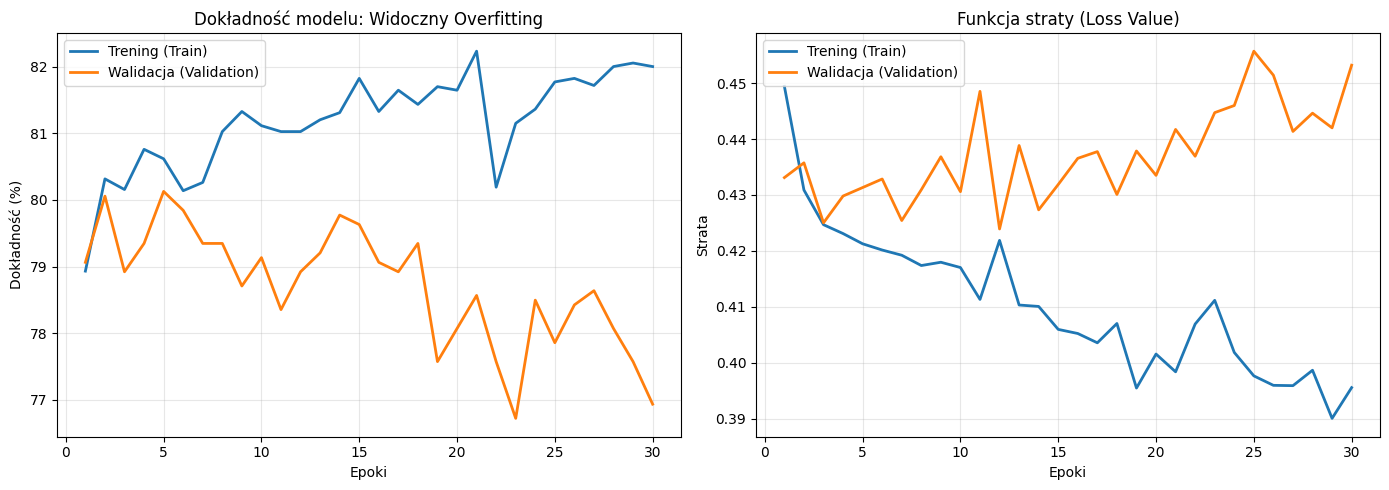

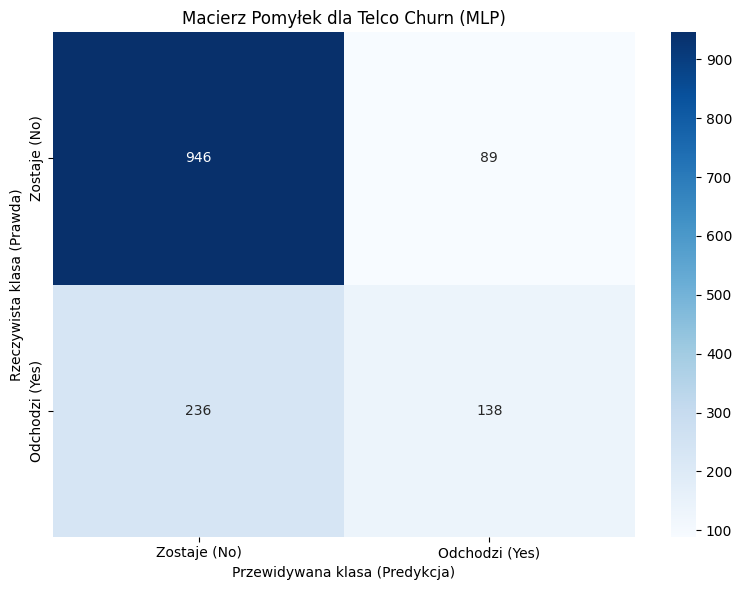

In [4]:
# Ewaluacja i macierz pomyłek
y_true, y_pred, _ = evaluate_best_model(best_model, test_loader, device, target_classes)
plot_single_history_overfitting(history)
plot_confusion_matrix_heatmap(y_true, y_pred, target_classes)
    


Seria eksperymentów (execute_series)

>>> TEST SERII: hidden_layers = [32]
Epoch 01 | Train Acc: 78.38% | Val Acc: 79.56% | Val Loss: 0.4276
Epoch 02 | Train Acc: 80.00% | Val Acc: 79.28% | Val Loss: 0.4303
Epoch 03 | Train Acc: 79.53% | Val Acc: 79.77% | Val Loss: 0.4301
Epoch 04 | Train Acc: 80.35% | Val Acc: 80.06% | Val Loss: 0.4264
Epoch 05 | Train Acc: 80.65% | Val Acc: 80.13% | Val Loss: 0.4279
Epoch 06 | Train Acc: 80.55% | Val Acc: 79.77% | Val Loss: 0.4246
Epoch 07 | Train Acc: 80.51% | Val Acc: 79.63% | Val Loss: 0.4286
Epoch 08 | Train Acc: 80.67% | Val Acc: 79.70% | Val Loss: 0.4247
Epoch 09 | Train Acc: 80.85% | Val Acc: 79.35% | Val Loss: 0.4270
Epoch 10 | Train Acc: 80.32% | Val Acc: 79.56% | Val Loss: 0.4328
Epoch 11 | Train Acc: 80.37% | Val Acc: 79.42% | Val Loss: 0.4267
Epoch 12 | Train Acc: 80.44% | Val Acc: 79.21% | Val Loss: 0.4267
Epoch 13 | Train Acc: 80.55% | Val Acc: 78.92% | Val Loss: 0.4270
Epoch 14 | Train Acc: 80.64% | Val Acc: 79.35% | Val Loss: 0.4256
E

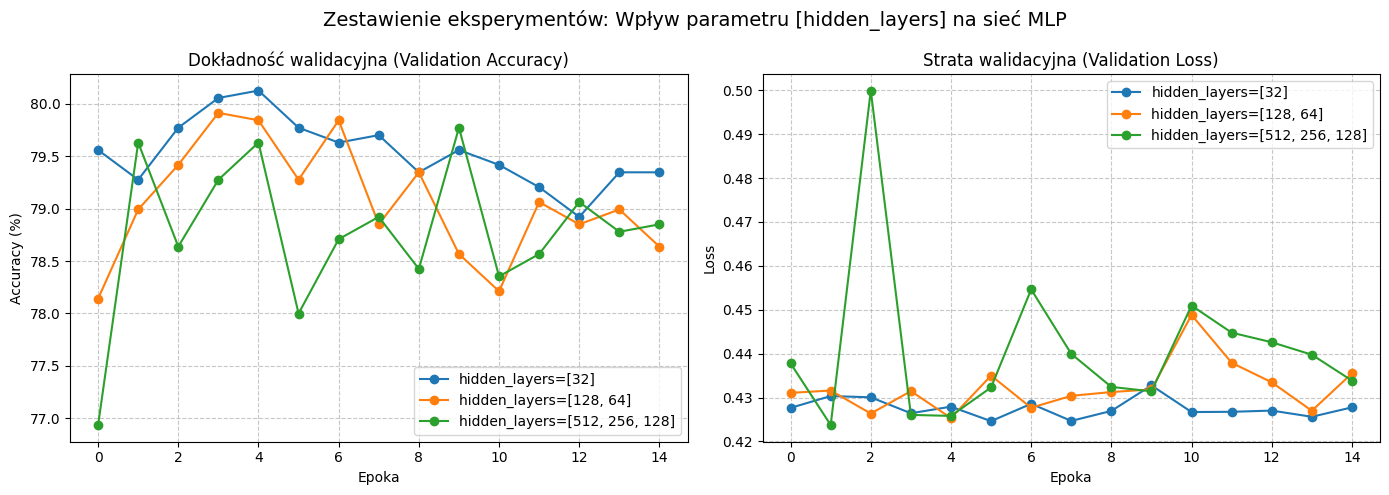

In [5]:
print("Seria eksperymentów (execute_series)")

architektury_testowe = [
    [32],               
    [128, 64],          
    [512, 256, 128]     
]
seria_wynikow = execute_series(
    device=device,
    base_cfg={**base_config, "epochs": 15}, 
    param_name="hidden_layers",
    values=architektury_testowe,
    train_loader=train_loader,
    test_loader=test_loader,
    input_size=input_features_dim
)

plot_series_results(seria_wynikow, "hidden_layers")
